# ROC-AUC for logistic regression classifiers

Two logistic regression models used in the pipeline:

1. **Island signal/noise classifier** — 16-D PCA-reduced, mean-pooled RNA-FM embeddings → binary logreg (proper ncRNA vs genomic noise)
2. **RNA-TOGA orthology classifier** — 3 features (synteny, global exon overlap, flank coverage) → binary logreg (ortholog vs paralog)

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split

matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"] = 42

REPO_ROOT = Path("..")
OUT_DIR = Path(".")

## 1. Island signal / noise classifier

In [2]:
island_data_path = REPO_ROOT / "modules" / "logreg_signal_noise" / "train.npz"
data = np.load(island_data_path)
X_train_isl, y_train_isl = data["X_train"], data["y_train"]
X_test_isl, y_test_isl = data["X_test"], data["y_test"]

print(f"Train: {X_train_isl.shape}  "
      f"({y_train_isl.sum():.0f} signal / {(1 - y_train_isl).sum():.0f} noise)")
print(f"Test:  {X_test_isl.shape}  "
      f"({y_test_isl.sum():.0f} signal / {(1 - y_test_isl).sum():.0f} noise)")

logreg_isl = LogisticRegression(max_iter=1000, class_weight="balanced")
logreg_isl.fit(X_train_isl, y_train_isl)

y_prob_isl = logreg_isl.predict_proba(X_test_isl)[:, 1]
auc_isl = roc_auc_score(y_test_isl, y_prob_isl)
fpr_isl, tpr_isl, _ = roc_curve(y_test_isl, y_prob_isl)
print(f"\nROC-AUC (island signal/noise): {auc_isl:.4f}")

Train: (7696, 16)  (3696 signal / 4000 noise)
Test:  (1924, 16)  (924 signal / 1000 noise)

ROC-AUC (island signal/noise): 0.9834


## 2. RNA-TOGA orthology classifier

In [3]:
toga_table_path = REPO_ROOT / "modules" / "rna_toga" / "original_toga_classification_table.tsv"
df_toga = pd.read_csv(toga_table_path, sep=",", engine="python")
df_toga = df_toga[df_toga["label"].isin(["ORTH", "PARA"])].copy()

print(f"ORTH/PARA rows: {len(df_toga):,}")
print(f"  ORTH: {(df_toga['label'] == 'ORTH').sum():,}")
print(f"  PARA: {(df_toga['label'] == 'PARA').sum():,}")

df_toga["synteny_log1p"] = np.log1p(df_toga["synteny"])
feature_cols = ["synteny_log1p", "gl_exo", "flank_cov"]
X_toga = df_toga[feature_cols].values
y_toga = (df_toga["label"] == "ORTH").astype(int).values

X_train_tog, X_test_tog, y_train_tog, y_test_tog = train_test_split(
    X_toga, y_toga, test_size=0.2, random_state=42, stratify=y_toga,
)

logreg_tog = LogisticRegression(
    class_weight="balanced", random_state=42, max_iter=1000,
)
logreg_tog.fit(X_train_tog, y_train_tog)

y_prob_tog = logreg_tog.predict_proba(X_test_tog)[:, 1]
auc_tog = roc_auc_score(y_test_tog, y_prob_tog)
fpr_tog, tpr_tog, _ = roc_curve(y_test_tog, y_prob_tog)
print(f"\nROC-AUC (RNA-TOGA orthology): {auc_tog:.4f}")

ORTH/PARA rows: 410,776
  ORTH: 79,065
  PARA: 331,711

ROC-AUC (RNA-TOGA orthology): 0.9816


## Combined ROC figure

Saved: logreg_roc_auc.pdf


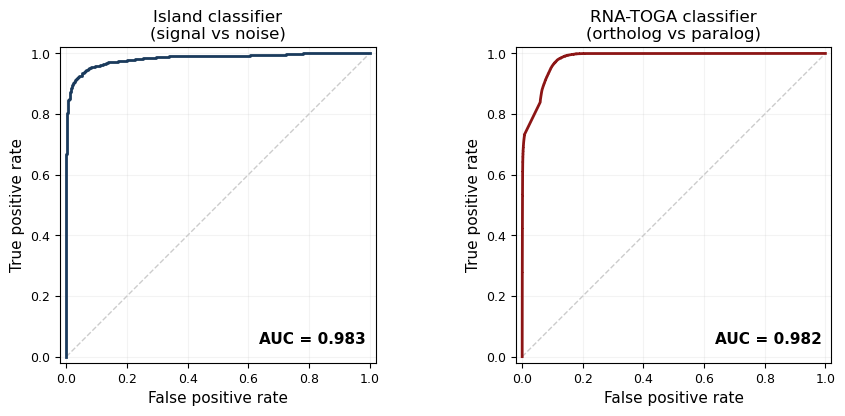

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4.2))

for ax, fpr, tpr, auc_val, title, color in [
    (ax1, fpr_isl, tpr_isl, auc_isl,
     "Island classifier\n(signal vs noise)", "#1a3a5c"),
    (ax2, fpr_tog, tpr_tog, auc_tog,
     "RNA-TOGA classifier\n(ortholog vs paralog)", "#8c1515"),
]:
    ax.plot(fpr, tpr, color=color, linewidth=2, zorder=3)
    ax.plot([0, 1], [0, 1], color="#cccccc", linewidth=1,
            linestyle="--", zorder=1)
    ax.text(
        0.97, 0.05, f"AUC = {auc_val:.3f}",
        transform=ax.transAxes, fontsize=11,
        ha="right", va="bottom", fontweight="bold",
    )
    ax.set_xlabel("False positive rate", fontsize=11)
    ax.set_ylabel("True positive rate", fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.set_aspect("equal")
    ax.tick_params(labelsize=9)
    ax.set_axisbelow(True)
    ax.grid(True, alpha=0.15)

fig.tight_layout(w_pad=3)

out_path = OUT_DIR / "logreg_roc_auc.pdf"
fig.savefig(out_path, bbox_inches="tight")
print(f"Saved: {out_path}")
plt.show()